## Torso mechanism Dynamics

![torso prototype.png](<attachment:torso prototype.png>)
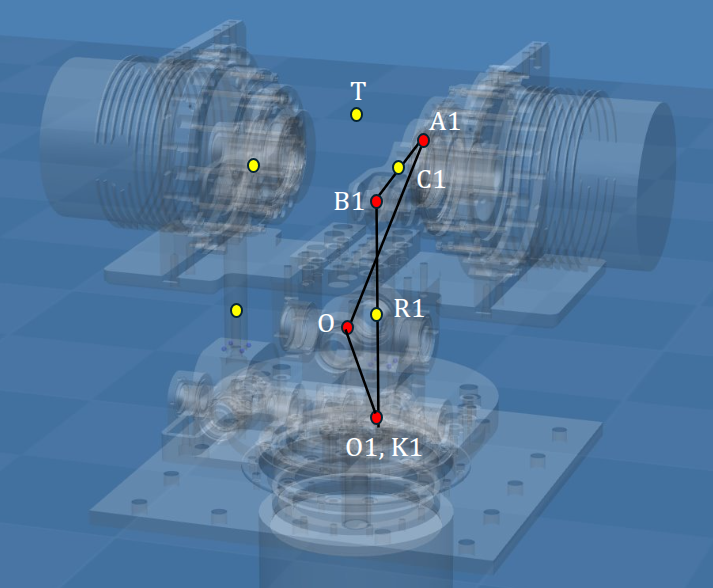

In [6]:
import sympy as sp
from scipy.optimize import fsolve
import sympy.physics.mechanics as me 
sp.init_printing(use_latex="mathjax")
me.init_vprinting()
from IPython.display import display

## Frames, Points, coordinates

In [7]:
N, B, U1, U2, L1, L2 = sp.symbols('N, B, U_1, U_2, L_1, L_2', cls=me.ReferenceFrame)
O, T, C1, C2, R1, R2 = sp.symbols('O, T, C_1, C_2, R_1, R_2', cls=me.Point)                                 # CoM points for the bodies
A1, A2, B1, B2, K1, K2, O1, O2 = sp.symbols('A_1, A_2, B_1, B_2, K_1, K_2, O_1, O_2', cls=me.Point)         # points for constraints / loop closure
alpha, beta = me.dynamicsymbols('alpha beta', real="True")
theta1, theta2 = me.dynamicsymbols('theta1:3', real="True")
psi1, psi2, psi3, psi4 = me.dynamicsymbols('psi1:5', real="True")
lt, ls, lc, lr, lf = sp.symbols('l_t, l_s, l_c, l_r, l_f' , positive="True", real="True")
m, g = sp.symbols('m, g', real="True", positive="True")
t = me.dynamicsymbols._t


p = sp.Matrix([ lt, ls, lc, lr, lf, m, g])
u1, u2, u3, u4, u5, u6, u7, u8 = me.dynamicsymbols('u1:9')
q = sp.Matrix([theta1, theta2])
q_r = sp.Matrix([alpha, beta, psi1, psi2, psi3, psi4])
q_N = q.col_join(q_r)

u = sp.Matrix([u1, u2])
u_r = sp.Matrix([u3, u4, u5, u6, u7, u8])
u_N = u.col_join(u_r)

qdot_N = q_N.diff(t)
udot = u.diff(t)

q_N_zero = {q:0 for q in q_N}
u_r_zero = {u: 0 for u in u_r}
u_N_zero = {u: 0 for u in u_N}
qdot_N_zero = {qd: 0 for qd in qdot_N}
u_d_zero = {ud: 0 for ud in udot}

q, q_r, q_N, u, u_r, u_N, qdot_N, udot

⎛            ⎡θ₁⎤              ⎡u₁⎤  ⎡θ₁̇⎤      ⎞
⎜            ⎢  ⎥              ⎢  ⎥  ⎢  ⎥      ⎟
⎜      ⎡α ⎤  ⎢θ₂⎥        ⎡u₃⎤  ⎢u₂⎥  ⎢θ₂̇⎥      ⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥      ⎟
⎜      ⎢β ⎥  ⎢α ⎥        ⎢u₄⎥  ⎢u₃⎥  ⎢α̇ ⎥      ⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥      ⎟
⎜⎡θ₁⎤  ⎢ψ₁⎥  ⎢β ⎥  ⎡u₁⎤  ⎢u₅⎥  ⎢u₄⎥  ⎢β̇ ⎥  ⎡u₁̇⎤⎟
⎜⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎜⎣θ₂⎦  ⎢ψ₂⎥  ⎢ψ₁⎥  ⎣u₂⎦  ⎢u₆⎥  ⎢u₅⎥  ⎢ψ₁̇⎥  ⎣u₂̇⎦⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥      ⎟
⎜      ⎢ψ₃⎥  ⎢ψ₂⎥        ⎢u₇⎥  ⎢u₆⎥  ⎢ψ₂̇⎥      ⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥      ⎟
⎜      ⎣ψ₄⎦  ⎢ψ₃⎥        ⎣u₈⎦  ⎢u₇⎥  ⎢ψ₃̇⎥      ⎟
⎜            ⎢  ⎥              ⎢  ⎥  ⎢  ⎥      ⎟
⎝            ⎣ψ₄⎦              ⎣u₈⎦  ⎣ψ₄̇⎦      ⎠

## Framing and coordinates setting

In [8]:
B.orient_body_fixed(N, (alpha, beta, 0), 'XYZ')
U1.orient_axis(B, B.y, theta1)
L1.orient_body_fixed(U1, (psi1, psi2, 0), 'XYZ')

U2.orient_axis(B, B.y, theta2)
L2.orient_body_fixed(U2, (psi3, psi4, 0), 'XYZ')

O1.set_pos(O, lc*N.x + ls/2*N.y - lf*N.z)
O2.set_pos(O, lc*N.x - ls/2*N.y - lf*N.z)
T.set_pos(O, lt*B.z)

A1.set_pos(O, ls/2*B.y + (lr-lf)*B.z)
C1.set_pos(T, lc/2*U1.x + ls/2*U1.y - (lt-lr+lf)*U1.z)
B1.set_pos(C1, lc/2*U1.x)
R1.set_pos(B1,- lr/2*L1.z)
K1.set_pos(R1,- lr/2*L1.z)

A2.set_pos(O,- ls/2*B.y + (lr-lf)*B.z)
C2.set_pos(T, lc/2*U2.x - ls/2*U2.y - (lt-lr+lf)*U2.z)
B2.set_pos(C2, lc/2*U2.x)
R2.set_pos(B2,- lr/2*L2.z)
K2.set_pos(R2,- lr/2*L2.z)


In [9]:
# position check

K1.pos_from(O).express(N).xreplace(q_N_zero)

In [10]:
# Position dependency

me.find_dynamicsymbols(T.pos_from(O), reference_frame=N), me.find_dynamicsymbols(C1.pos_from(O), reference_frame=N), me.find_dynamicsymbols(C2.pos_from(O), reference_frame=N), me.find_dynamicsymbols(R1.pos_from(O), reference_frame=N),me.find_dynamicsymbols(K1.pos_from(O), reference_frame=N), me.find_dynamicsymbols(R2.pos_from(O), reference_frame=N),  me.find_dynamicsymbols(K2.pos_from(O), reference_frame=N)

In [11]:
# loop closure equations

loop_closure1 = K1.pos_from(O) - O1.pos_from(O)
loop_closure2 = K2.pos_from(O) - O2.pos_from(O)
rod_constraint1 = B1.pos_from(O) - O1.pos_from(O)
rod_constraint2 = B2.pos_from(O) - O2.pos_from(O)

constraints = [
    loop_closure1,
    loop_closure2,
    rod_constraint1,
    rod_constraint2
    ]

# for c in constraints:
#     display(c.express(N))


## Algebraic Holonomic constraint equations

In [12]:
# Holonomic constraints

fh = sp.Matrix([
    loop_closure1.dot(N.y) - 0,
    loop_closure2.dot(N.y) - 0,
    loop_closure1.dot(N.z) - 0,
    loop_closure2.dot(N.z) - 0,
    rod_constraint1.dot(rod_constraint1) - lr**2,
    rod_constraint2.dot(rod_constraint2) - lr**2,
    # loop_closure1.dot(N.x) - 0,
    # loop_closure2.dot(N.x) - 0,
    ])

fh = fh.applyfunc(lambda i: sp.simplify(sp.trigsimp(i)))
fh


⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

#### Constraint equation dependents

In [13]:
me.find_dynamicsymbols(fh[0]), me.find_dynamicsymbols(fh[1]),


In [14]:
me.find_dynamicsymbols(fh[2]), me.find_dynamicsymbols(fh[3]),
    

In [15]:
me.find_dynamicsymbols(fh[4]), me.find_dynamicsymbols(fh[5])

In [16]:
fh[4].free_symbols, fh[5].free_symbols

## Kinematic differential equations

In [17]:
fk = sp.Matrix([
    theta1.diff(t) - u1,
    theta2.diff(t) - u2,
    alpha.diff(t) - u3,
    beta.diff(t) - u4,
    psi1.diff(t) - u5,
    psi2.diff(t) - u6,
    psi3.diff(t) - u7,
    psi4.diff(t) - u8,
])

Mk = fk.jacobian(qdot_N)
gk = fk.xreplace(qdot_N_zero)
qdot_N_sol = -Mk.LUsolve(gk)


In [18]:
Mk, qdot_N, gk

⎛⎡1  0  0  0  0  0  0  0⎤  ⎡θ₁̇⎤  ⎡-u₁⎤⎞
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  1  0  0  0  0  0  0⎥  ⎢θ₂̇⎥  ⎢-u₂⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  1  0  0  0  0  0⎥  ⎢α̇ ⎥  ⎢-u₃⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  0  1  0  0  0  0⎥  ⎢β̇ ⎥  ⎢-u₄⎥⎟
⎜⎢                      ⎥, ⎢  ⎥, ⎢   ⎥⎟
⎜⎢0  0  0  0  1  0  0  0⎥  ⎢ψ₁̇⎥  ⎢-u₅⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  0  0  0  1  0  0⎥  ⎢ψ₂̇⎥  ⎢-u₆⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  0  0  0  0  1  0⎥  ⎢ψ₃̇⎥  ⎢-u₇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎝⎣0  0  0  0  0  0  0  1⎦  ⎣ψ₄̇⎦  ⎣-u₈⎦⎠

In [19]:

qdot_N_replace = dict(zip(qdot_N, qdot_N_sol))
qdot_N_replace

Below part fh_d is done to replace the dependent speeds in terms of the generalised speeds

(which might not be needed because I wouldve already known the mapping of the dependent coordinates from the algebaric holonomic constraint equations and hence dependent speeds are also known)

In [20]:
# fh_d = fh.diff(t).xreplace(qdot_N_replace)

# Mh_d = fh_d.jacobian(u_r)
# gh_d = fh_d.xreplace(u_r_zero)
# u_r_sol = -Mh_d.LUsolve(gh_d)

# u_r_replace = dict(zip(u_r, u_r_sol))

# me.find_dynamicsymbols(fh_d)

### Linear & Angular velocities

In [29]:
O.set_vel(N, 0)
T.set_vel(B, 0)
C1.set_vel(U1, 0)
C2.set_vel(U2, 0)
R1.set_vel(L1, 0)
R2.set_vel(L2, 0)

T.set_vel(N, T.v2pt_theory(O, N, B))
C1.set_vel(N, C1.v2pt_theory(O, N, U1))
C2.set_vel(N, C2.v2pt_theory(O, N, U1))

C1.vel(N)